<a href="https://colab.research.google.com/github/OlaniyiSegunIsrael/Assignment-15-SO/blob/main/Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Assignment 15: Loan Default Prediction

##Assignment link
- Google colab: https://colab.research.google.com/drive/1w4qNRiVNzxwwTCP-T0_ANUvISi4DPaWz?usp=sharing

- Git Hub: https://github.com/OlaniyiSegunIsrael/Assignment-15-SO

In [23]:
!apt-get install -y git
!git config --global user.email "segun.olaniyi@students.williscollege.com"
!git config --global user.name "OlaniyiSegunIsrael"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [24]:
!git clone https://github.com/OlaniyiSegunIsrael/Assignment-15-SO.git
%cd Assignment-15-SO
!ls

Cloning into 'Assignment-15-SO'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Assignment-15-SO
README.md


In [25]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [1]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import shap

In [2]:
# STEP 2: LOAD DATASET

df = pd.read_csv("/content/bank-loan.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
   age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0


In [3]:
# STEP 3: EDA (EXPLORATORY DATA ANALYSIS)

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB
None

Summary Statistics:
              age          ed      employ     address      income     debtinc  \
count  850.000000  850.000000  850.000000  850.000000  850.000000  850.000000   
mean    35.029412    1.710588    8.565882    8.371765   46.675294   10.171647   
std      8.041432    0.927784    6.777884    6.895016   38.543054    6.719441   
min     20.000000    1.000000    0.000000    0.0000

In [6]:
# STEP 4: DATA CLEANING

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

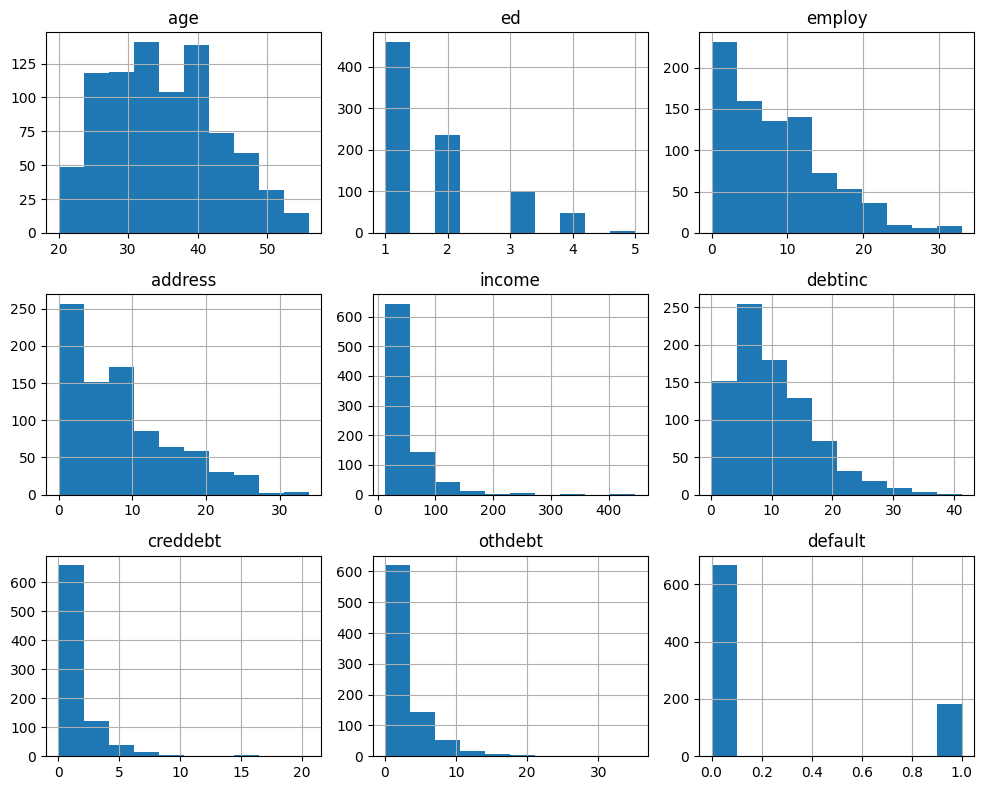

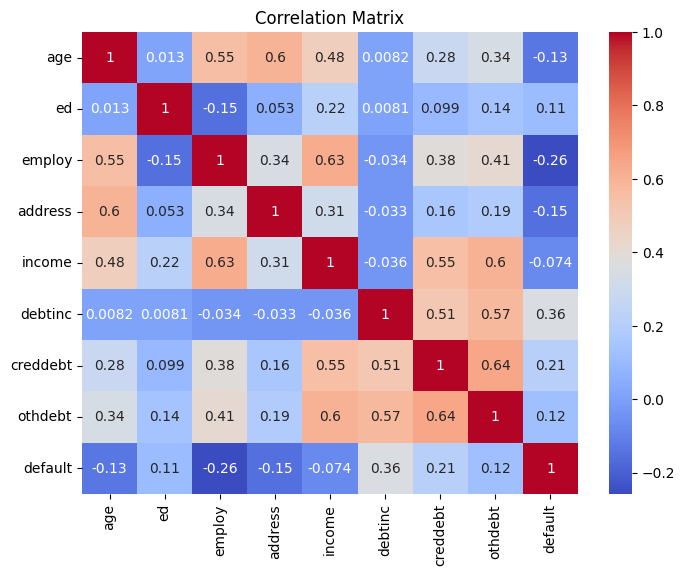

In [7]:
# Visualize distributions
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

print()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [8]:
# STEP 5: FEATURE ENGINEERING

# Create new feature column
if 'income' in df.columns and 'debt' in df.columns:
    df['income_debt_ratio'] = df['income'] / (df['debt'] + 1)

In [9]:
# STEP 6: SPLIT DATA

# Target column is named 'default'
target_column = 'default' if 'default' in df.columns else df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [10]:
# STEP 7: MODEL TRAINING

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
# STEP 8: MODEL EVALUATION

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8176470588235294

Confusion Matrix:
[[125   8]
 [ 23  14]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89       133
         1.0       0.64      0.38      0.47        37

    accuracy                           0.82       170
   macro avg       0.74      0.66      0.68       170
weighted avg       0.80      0.82      0.80       170



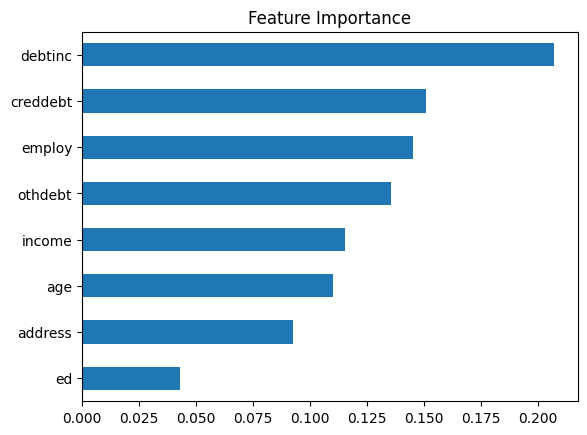

In [12]:
# STEP 9: FEATURE IMPORTANCE

importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

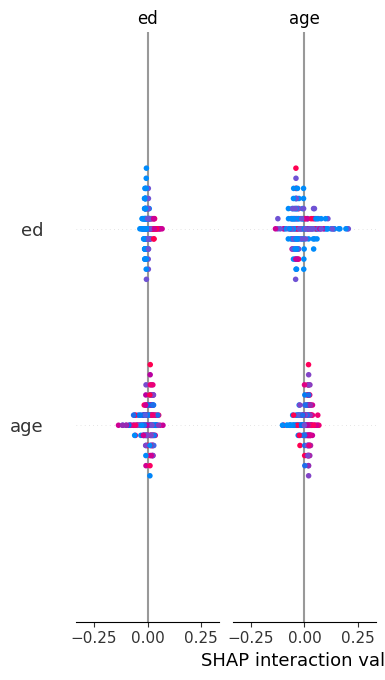

In [14]:
#TEP 10: SHAP EXPLAINABILITY

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)

In [22]:
# STEP 11: FAIRNESS ANALYSIS (USING AGE)

if 'age' in df.columns:
    # Find index of age column
    age_index = list(X.columns).index('age')

    # Define groups (example: young vs old)
    young_group = X_test[:, age_index] < 40
    old_group = X_test[:, age_index] >= 40

    print("\nFairness Analysis (Age Groups):")

    print("Young Group Accuracy:",
          accuracy_score(y_test[young_group], y_pred[young_group]))

    print("Older Group Accuracy:",
          accuracy_score(y_test[old_group], y_pred[old_group]))
else:
    print("No suitable fairness column (like age) found.")




Fairness Analysis (Age Groups):
Young Group Accuracy: 0.8176470588235294
Older Group Accuracy: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
